In [12]:
!pip install lifelines

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
from lifelines import CoxPHFitter
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
from lifelines import KaplanMeierFitter
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/kaggle/input/colorectal-cancer-patients/Colorectal Cancer Patient Data.csv')

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       63 non-null     int64  
 1   ID_REF           62 non-null     object 
 2   Age (in years)   62 non-null     float64
 3   Dukes Stage      62 non-null     object 
 4   Gender           62 non-null     object 
 5   Location         62 non-null     object 
 6   DFS (in months)  62 non-null     float64
 7   DFS event        62 non-null     float64
 8   Adj_Radio        62 non-null     float64
 9   Adj_Chem         62 non-null     float64
dtypes: float64(5), int64(1), object(4)
memory usage: 5.0+ KB
None


<div>
<div>ID_REF - Patient ID.</div>
<div>Age (in years) - Patient's age at the time of diagnosis (numeric variable).</div>
<div>Dukes Stage - The stage of colorectal cancer according to the Dukes classification (categorical variable: A, B, C, D).</div>
<div>Gender - The sex of the patient (categorical variable: Male or Female).</div>
<div>Location - Tumor location (categorical variable: Left, Right, Colon, Rectum).</div>
<div>DFS (in months) - Recurrence-free survival in months (numeric variable).</div>
<div>DFS event - Survival event (target: 1 = recurrence or death, 0 = no recurrence).</div>
<div>Adj_Radio - Receipt of radiation therapy (1 = received, 0 = did not receive).</div>
<div>Adj_Chem - Receipt of chemotherapy (1 = received, 0 = did not receive).</div>
<br />
<div>Target variable: DFS event</div>
<div>Time variable: DFS (in months)</div>
</div>

In [11]:
df_cleaned = df.drop(columns=['Unnamed: 0', 'ID_REF'])

df_cleaned.columns = ['Age', 'Dukes_Stage', 'Gender', 'Location', 'DFS_months', 'DFS_event', 'Adj_Radio', 'Adj_Chem']

df_cleaned = df_cleaned.dropna()

kmf = KaplanMeierFitter()

age_group = df_cleaned['Age']
dfs_months = df_cleaned['DFS_months']
dfs_event = df_cleaned['DFS_event']

kmf.fit(durations=dfs_months, event_observed=dfs_event)

<lifelines.KaplanMeierFitter:"KM_estimate", fitted with 62 total observations, 25 right-censored observations>

<div>
<div>General plot of survival analysis according to age</div>
</div>

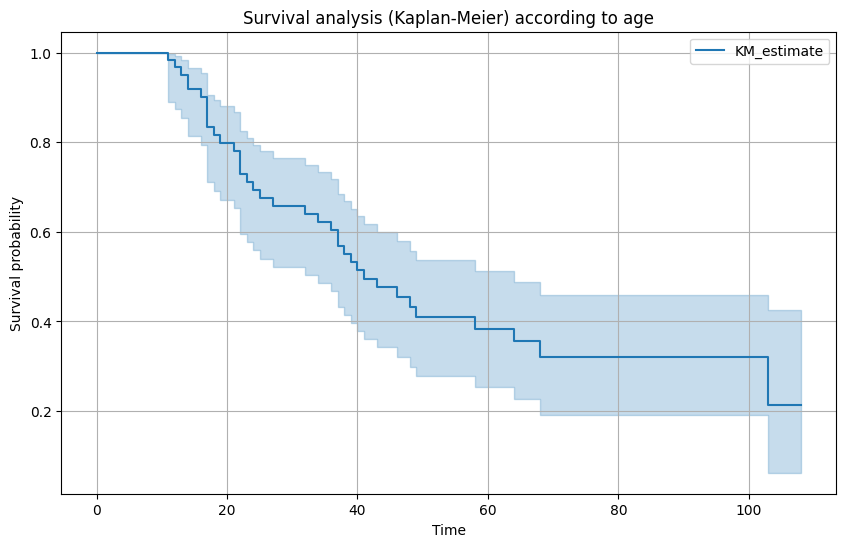

In [12]:
plt.figure(figsize=(10, 6))
kmf.plot_survival_function()
plt.title('Survival analysis (Kaplan-Meier) according to age')
plt.xlabel('Time')
plt.ylabel('Survival probability')
plt.grid(True)
plt.show()

<div>
<div>Overall analysis shows that survival decreases over time, which is expected in patients with colorectal cancer.</div>
</div>

<div>
<div>Graph of survival analysis depending on the selected groups</div>
</div>

In [13]:
df_encoded = pd.get_dummies(df_cleaned, columns=['Dukes_Stage', 'Gender', 'Location'], drop_first=True)

X = df_encoded.drop(columns=['DFS_event', 'DFS_months'])
y = df_encoded['DFS_event']

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_,
    'P-value': selector.pvalues_
})

print("Features:")
print(scores.sort_values(by='P-value', ascending=False))

Features:
           Feature     Score   P-value
7    Location_Left  0.001236  0.972077
5    Dukes_Stage_D  0.010813  0.917529
3    Dukes_Stage_B  0.154839  0.695348
2         Adj_Chem  0.212643  0.646371
4    Dukes_Stage_C  0.260898  0.611378
6      Gender_Male  1.021342  0.316259
0              Age  1.282942  0.261859
1        Adj_Radio  1.951790  0.167540
9   Location_Right  2.908636  0.093279
8  Location_Rectum  3.538962  0.064797


<div>
<div>Since no significant variables turned out to be significant, we will plot the survival rate by the closest significant variable, which in this case is the tumor location in the rectum.</div>
<div><br />We will categorize the patients into two groups: those with tumors located in the rectum and those with tumors in other locations, and analyze their survival probabilities over tim/></div>
</div>

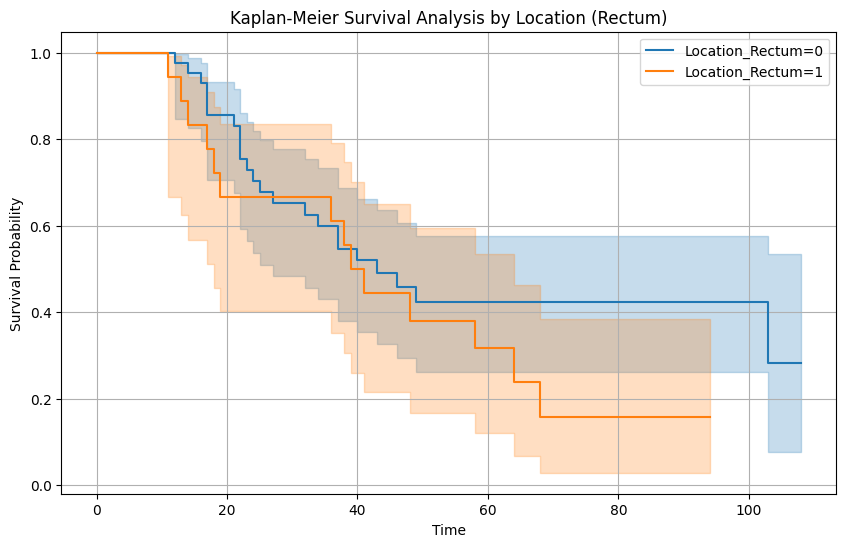

In [6]:
kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

median_location_rectum = df_cleaned['Location'].apply(lambda x: 1 if x == 'Rectum' else 0).median()
df_cleaned['Location_Rectum_group'] = df_cleaned['Location'].apply(lambda x: 1 if x == 'Rectum' else 0)

for group in df_cleaned['Location_Rectum_group'].unique():
    mask = df_cleaned['Location_Rectum_group'] == group
    kmf.fit(df_cleaned[mask]['DFS_months'], event_observed=df_cleaned[mask]['DFS_event'], label=f'Location_Rectum={group}')
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Analysis by Location (Rectum)')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

<div>
<div>Groups of patients with tumors in the rectum and in other locations show differences in survival.</div>
<div><br />Patients with tumors in the rectum have a lower survival rate.</div>
</div>

<div>
<div>Application of PCA for dimensionality reduction</div>
</div>

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

pca_components = pd.DataFrame(pca.components_, columns=X.columns, index=['PCA1', 'PCA2'])
print("\nContributions of baseline traits to PCA1 and PCA2:")
print(pca_components.T)


Contributions of baseline traits to PCA1 and PCA2:
                     PCA1      PCA2
Age              0.999833  0.013005
Adj_Radio        0.009006 -0.343331
Adj_Chem         0.002962  0.246288
Dukes_Stage_B   -0.010304  0.137560
Dukes_Stage_C    0.005166 -0.452607
Dukes_Stage_D   -0.003641  0.159971
Gender_Male      0.000284  0.106829
Location_Left    0.001755 -0.409850
Location_Rectum  0.006442 -0.202928
Location_Right  -0.007264  0.592757


<div>
<div>PCA1:</div>
<div>Age (0.999833): Age has the strongest positive influence on PCA1.</div>
<div>Adj_Radio (0.009006): Receipt of radiation therapy contributes positively to PCA1, albeit minimally.</div>
<div>Adj_Chem (0.002962): Receipt of chemotherapy also contributes positively to PCA1.</div>
<div>Dukes_Stage_B (-0.010304): Patients classified as Dukes Stage B show a slight negative influence on PCA1.</div>
<div>Dukes_Stage_C (0.005166): Dukes Stage C has a minor positive influence on PCA1.</div>
<div>Dukes_Stage_D (-0.003641): Dukes Stage D shows a slight negative influence on PCA1.</div>
<div>Gender_Male (0.000284): Male gender has a negligible positive influence on PCA1.</div>
<div>Location_Left (0.001755): Tumor location on the left side contributes positively to PCA1.</div>
<div>Location_Rectum (0.006442): Tumor location in the rectum contributes positively to PCA1.</div>
<div>Location_Right (-0.007264): Tumor location on the right side has a negative influence on PCA1.</div>
<br />
<div>PCA2:</div>
<div>Location_Right (0.592757): Tumor location on the right side has the strongest positive influence on PCA2.</div>
<div>Adj_Chem (0.246288): Receipt of chemotherapy contributes positively to PCA2.</div>
<div>Gender_Male (0.106829): Male gender contributes positively to PCA2.</div>
<div>Dukes_Stage_B (0.137560): Dukes Stage B shows a moderate positive influence on PCA2.</div>
<div>Dukes_Stage_C (-0.452607): Dukes Stage C has the strongest negative influence on PCA2.</div>
<div>Dukes_Stage_D (0.159971): Dukes Stage D contributes positively to PCA2.</div>
<div>Location_Left (-0.409850): Tumor location on the left side has a strong negative influence on PCA2.</div>
<div>Location_Rectum (-0.202928): Tumor location in the rectum also contributes negatively to PCA2.</div>
<div>Adj_Radio (-0.343331): Receipt of radiation therapy has a notable negative impact on PCA2.</div>
</div>

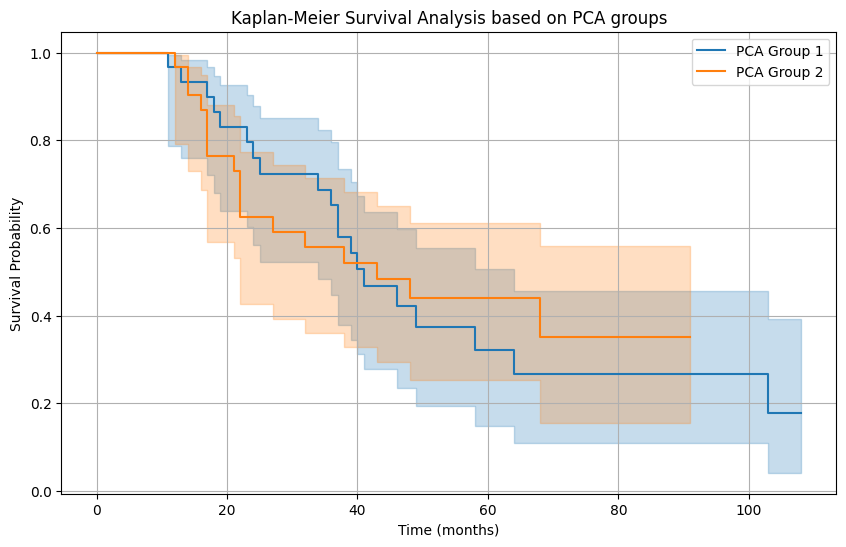

In [8]:
df_pca = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
df_pca['DFS_months'] = df_cleaned['DFS_months']
df_pca['DFS_event'] = df_cleaned['DFS_event']

kmf = KaplanMeierFitter()
plt.figure(figsize=(10, 6))

median_pca1 = df_pca['PCA1'].median()
df_pca['PCA1_group'] = np.where(df_pca['PCA1'] > median_pca1, 'Group 1', 'Group 2')

for group in df_pca['PCA1_group'].unique():
    mask = df_pca['PCA1_group'] == group
    kmf.fit(df_pca[mask]['DFS_months'], event_observed=df_pca[mask]['DFS_event'], label=f'PCA {group}')
    kmf.plot_survival_function()

plt.title('Kaplan-Meier Survival Analysis based on PCA groups')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

<div>
<div>Patients in Group 2 (higher PCA2) show better survival probability over time compared to Group 1.</div>
</div>

In [14]:
# More thorough data exploration
print(df.describe())
print(df.isnull().sum())

# Visualize distributions
import seaborn as sns
for col in df_cleaned.columns:
    if df_cleaned[col].dtype in ['float64', 'int64']:
        plt.figure(figsize=(8,4))
        sns.histplot(df_cleaned[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.show()
    else:
        plt.figure(figsize=(8,4))
        sns.countplot(data=df_cleaned, x=col)
        plt.title(f'Count of {col}')
        plt.xticks(rotation=45)
        plt.show()

       Unnamed: 0  Age (in years)  DFS (in months)  DFS event  Adj_Radio  \
count   63.000000       62.000000        62.000000  62.000000  62.000000   
mean    31.000000       61.112903        41.774194   0.596774   0.532258   
std     18.330303        9.581582        26.288076   0.494550   0.503032   
min      0.000000       28.000000         4.000000   0.000000   0.000000   
25%     15.500000       56.250000        19.500000   0.000000   0.000000   
50%     31.000000       62.000000        38.000000   1.000000   1.000000   
75%     46.500000       67.000000        57.500000   1.000000   1.000000   
max     62.000000       78.000000       108.000000   1.000000   1.000000   

        Adj_Chem  
count  62.000000  
mean    0.483871  
std     0.503819  
min     0.000000  
25%     0.000000  
50%     0.000000  
75%     1.000000  
max     1.000000  
Unnamed: 0         0
ID_REF             1
Age (in years)     1
Dukes Stage        1
Gender             1
Location           1
DFS (in months)   

NameError: name 'df_cleaned' is not defined

In [14]:
# Create more meaningful features
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=[0,50,60,70,100], 
                                labels=['<50','50-60','60-70','70+'])

# Create interaction terms between treatment and stage
df_cleaned['Radio_Stage'] = df_cleaned['Adj_Radio'].astype(str) + "_" + df_cleaned['Dukes_Stage']
df_cleaned['Chem_Stage'] = df_cleaned['Adj_Chem'].astype(str) + "_" + df_cleaned['Dukes_Stage']

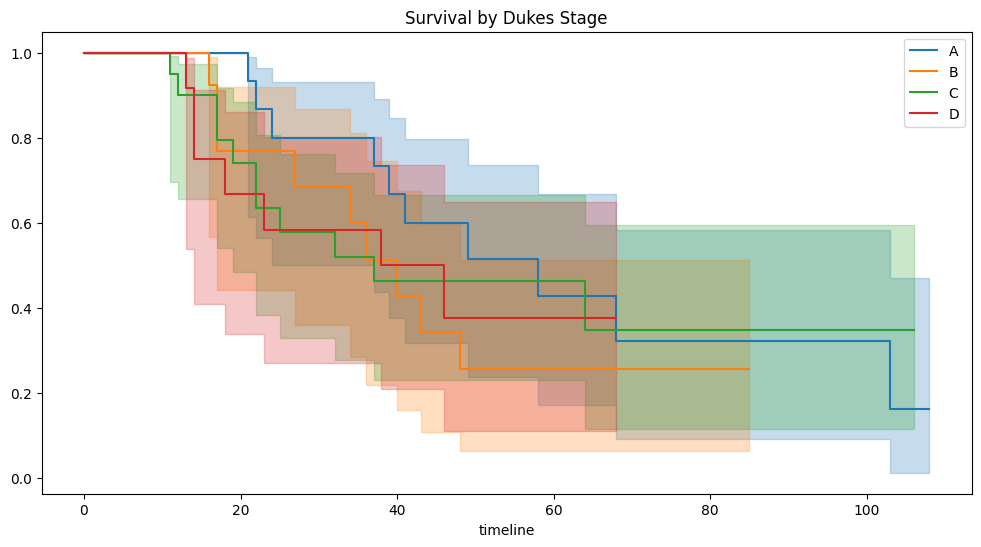

ValueError: Cannot cast object dtype to float64

In [15]:
# Compare survival between different groups
plt.figure(figsize=(12,6))
for stage in df_cleaned['Dukes_Stage'].unique():
    mask = df_cleaned['Dukes_Stage'] == stage
    kmf.fit(df_cleaned['DFS_months'][mask], df_cleaned['DFS_event'][mask], label=stage)
    kmf.plot_survival_function()
plt.title('Survival by Dukes Stage')
plt.show()

# Fit Cox Proportional Hazards model
cph = CoxPHFitter()
df_for_cph = pd.get_dummies(df_cleaned, columns=['Dukes_Stage', 'Gender', 'Location'], drop_first=True)
cph.fit(df_for_cph, duration_col='DFS_months', event_col='DFS_event')
cph.print_summary()

# Plot coefficients
plt.figure(figsize=(10,6))
cph.plot()
plt.title('Cox PH Model Coefficients')
plt.show()

In [15]:
# Install required packages
!pip install lifelines pandas numpy scikit-learn matplotlib


Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63 entries, 0 to 62
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       63 non-null     int64  
 1   ID_REF           62 non-null     object 
 2   Age (in years)   62 non-null     float64
 3   Dukes Stage      62 non-null     object 
 4   Gender           62 non-null     object 
 5   Location         62 non-null     object 
 6   DFS (in months)  62 non-null     float64
 7   DFS event        62 non-null     float64
 8   Adj_Radio        62 non-null     float64
 9   Adj_Chem         62 non-null     float64
dtypes: float64(5), int64(1), object(4)
memory usage: 5.0+ KB
None

Running Cox Proportional Hazards Model...
Creating dummies for: ['Dukes_Stage', 'Gender', 'Location', 'Treatment', 'Age_Group']

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 62 total observations, 25 right-censored observations>
             duration col = 'DFS_months'
                event col = 'DFS_event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 62
number of events observed = 37
   partial log-likelihood = -126.77
         time fit was run = 2025-07-01 07:46:00 UTC

---
                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                            
Age                  0.01      1.01      0.02           -0.04            0.06                0.96                1.06
Adj_Radio           -0.21      0.81      0.57           -1.33            0.91                0.26                2.49
Adj_Chem            -0.00      1.00      0.57           -1.12            1.11                0.33                3.03
Dukes_Stage_B        0.47      1.60      0.42           -0.36            1.30                0.70                3.68
Dukes_Stage_C        0.21      1.23      0.39           -0.56            0.98                0.57                2.66
Dukes_Stage_D        0.38      1.46      0.46           -0.53            1.28                0.59                3.60
Gender_Male          0.13      1.14      0.39           -0.64            0.91                0.53                2.47
Location_Left        0.32      1.38      0.49           -0.64            1.29                0.53                3.63
Location_Rectum      0.50      1.65      0.53           -0.53            1.53                0.59                4.61
Location_Right      -0.19      0.83      0.50           -1.16            0.78                0.31                2.19
Treatment_Chemo      0.19      1.21      0.61           -1.00            1.39                0.37                4.01
Treatment_None       0.09      1.09      0.70           -1.28            1.45                0.28                4.28
Treatment_Radiation -0.06      0.94      0.59           -1.21            1.10                0.30                3.00
Age_Group_50-65      0.52      1.68      0.46           -0.38            1.41                0.69                4.12
Age_Group_65+        0.33      1.39      0.58           -0.81            1.47                0.44                4.36

                     cmp to     z    p  -log2(p)
covariate                                       
Age                    0.00  0.41 0.68      0.55
Adj_Radio              0.00 -0.37 0.71      0.49
Adj_Chem               0.00 -0.01 0.99      0.01
Dukes_Stage_B          0.00  1.11 0.27      1.91
Dukes_Stage_C          0.00  0.53 0.60      0.74
Dukes_Stage_D          0.00  0.81 0.42      1.27
Gender_Male            0.00  0.34 0.74      0.44
Location_Left          0.00  0.66 0.51      0.97
Location_Rectum        0.00  0.95 0.34      1.54
Location_Right         0.00 -0.38 0.70      0.51
Treatment_Chemo        0.00  0.31 0.75      0.41
Treatment_None         0.00  0.13 0.90      0.15
Treatment_Radiation    0.00 -0.10 0.92      0.12
Age_Group_50-65        0.00  1.13 0.26      1.96
Age_Group_65+          0.00  0.56 0.57      0.80
---
Concordance = 0.63
Partial AIC = 283.53
log-likelihood ratio test = 6.82 on 15 df
-log2(p) of ll-ratio test = 0.06

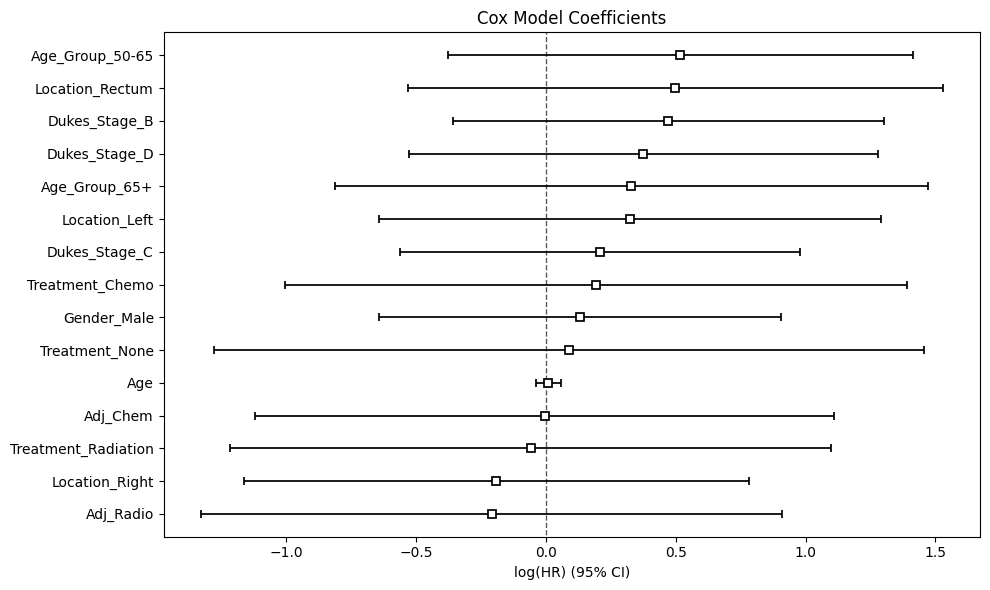

In [16]:
import pandas as pd
import numpy as np
from lifelines import CoxPHFitter, KaplanMeierFitter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load and preprocess data
def load_and_preprocess_data(filepath):
    df = pd.read_csv(filepath)
    
    # Display basic info
    print("Data Info:")
    print(df.info())
    
    # Drop unnecessary columns
    df_cleaned = df.drop(columns=['Unnamed: 0', 'ID_REF'], errors='ignore')
    
    # Rename columns for consistency
    df_cleaned.columns = ['Age', 'Dukes_Stage', 'Gender', 'Location', 'DFS_months', 'DFS_event', 'Adj_Radio', 'Adj_Chem']
    
    # Drop rows with missing values
    df_cleaned = df_cleaned.dropna()
    
    # Convert numeric columns to correct types
    numeric_cols = ['Age', 'DFS_months', 'DFS_event', 'Adj_Radio', 'Adj_Chem']
    for col in numeric_cols:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
    
    # Drop any rows that couldn't be converted
    df_cleaned = df_cleaned.dropna()
    
    # Create Age_Group if Age exists
    if 'Age' in df_cleaned.columns:
        df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'],
                                        bins=[0, 50, 65, 100],
                                        labels=['<50', '50-65', '65+'])
    
    return df_cleaned

# Load and clean the data
df_cleaned = load_and_preprocess_data('/kaggle/input/colorectal-cancer-patients/Colorectal Cancer Patient Data.csv')

# Enhanced Cox Proportional Hazards Model with robust error handling
def run_cox_model(df):
    # First check which categorical columns actually exist
    categorical_cols = []
    for col in ['Dukes_Stage', 'Gender', 'Location', 'Treatment', 'Age_Group']:
        if col in df.columns:
            categorical_cols.append(col)
    
    if not categorical_cols:
        print("No categorical columns found for dummy encoding")
        df_encoded = df.copy()
    else:
        print(f"Creating dummies for: {categorical_cols}")
        df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    
    # Ensure we have the required columns
    required_cols = ['DFS_months', 'DFS_event']
    if not all(col in df_encoded.columns for col in required_cols):
        print("Missing required columns for Cox model")
        return None
    
    # Convert all columns to numeric and drop NA
    df_encoded = df_encoded.apply(pd.to_numeric, errors='coerce').dropna()
    
    # Check for zero variance columns and remove them
    numeric_cols = df_encoded.select_dtypes(include=np.number).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in ['DFS_months', 'DFS_event']]
    
    zero_var_cols = [col for col in numeric_cols if df_encoded[col].nunique() <= 1]
    if zero_var_cols:
        print(f"Removing zero-variance columns: {zero_var_cols}")
        df_encoded = df_encoded.drop(columns=zero_var_cols)
    
    # Check if we still have enough data
    if len(df_encoded) < 10:
        print("Not enough data after cleaning (n < 10)")
        return None
    
    try:
        # Use a small penalizer to improve numerical stability
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(df_encoded, duration_col='DFS_months', event_col='DFS_event')
        
        print("\nCox Proportional Hazards Model Summary:")
        cph.print_summary()
        
        plt.figure(figsize=(10, 6))
        cph.plot()
        plt.title('Cox Model Coefficients')
        plt.tight_layout()
        plt.show()
        
        return cph
    
    except Exception as e:
        print(f"Error fitting Cox model: {str(e)}")
        return None

# Create Treatment Groups if the columns exist
if all(col in df_cleaned.columns for col in ['Adj_Radio', 'Adj_Chem']):
    df_cleaned['Treatment'] = 'None'
    df_cleaned.loc[(df_cleaned['Adj_Radio'] == 1) & (df_cleaned['Adj_Chem'] == 0), 'Treatment'] = 'Radiation'
    df_cleaned.loc[(df_cleaned['Adj_Chem'] == 1) & (df_cleaned['Adj_Radio'] == 0), 'Treatment'] = 'Chemo'
    df_cleaned.loc[(df_cleaned['Adj_Radio'] == 1) & (df_cleaned['Adj_Chem'] == 1), 'Treatment'] = 'Both'

# Run Cox model
print("\nRunning Cox Proportional Hazards Model...")
cph_model = run_cox_model(df_cleaned)

# If initial model fails, try a simplified version
if cph_model is None:
    print("\nAttempting simplified Cox model with only key variables...")
    # Select only columns that definitely exist
    available_cols = [col for col in ['Age', 'Dukes_Stage', 'DFS_months', 'DFS_event', 'Treatment'] 
                     if col in df_cleaned.columns]
    simplified_df = df_cleaned[available_cols].copy()
    cph_model = run_cox_model(simplified_df)

In [18]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_cleaned, columns=['Dukes_Stage', 'Gender', 'Location'], drop_first=True)

# Define features and target
X = df_encoded.drop(columns=['DFS_event', 'DFS_months'])
y = df_encoded['DFS_event']

# Convert to numeric just in case
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
y = pd.to_numeric(y, errors='coerce').fillna(0).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train SVM classifier
svm_model = make_pipeline(StandardScaler(), SVC())
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.33      0.46         9
           1       0.60      0.90      0.72        10

    accuracy                           0.63        19
   macro avg       0.68      0.62      0.59        19
weighted avg       0.67      0.63      0.60        19



In [ ]:
pip install scikit-survival

In [19]:
from sksurv.svm import FastKernelSurvivalSVM
from sksurv.util import Surv

# Convert to sksurv format
y_surv = Surv.from_dataframe(event='DFS_event', time='DFS_months', data=df_encoded)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_surv, test_size=0.3, random_state=42)

# Fit Survival SVM
svm_surv = FastKernelSurvivalSVM(kernel="rbf", alpha=0.1, max_iter=100)
svm_surv.fit(X_train, y_train)

# Evaluate
score = svm_surv.score(X_test, y_test)
print(f"Concordance Index: {score:.3f}")

Concordance Index: 0.730


In [6]:
pip install -U scikit-survival

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install git+https://github.com/sebp/scikit-survival.git 

  Cloning https://github.com/sebp/scikit-survival.git to /tmp/pip-req-build-qvz7l1yg
  Running command git clone --filter=blob:none --quiet https://github.com/sebp/scikit-survival.git /tmp/pip-req-build-qvz7l1yg
  Resolved https://github.com/sebp/scikit-survival.git to commit 7727aacc1317e157bf20f49ed660a9c73ac7092c
  Running command git submodule update --init --recursive -q
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scikit_learn-1.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.5/297.5 kB 7.6 MB/s eta 0:00:00:00:01
Using cached scikit_learn-1.7.0-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.3 MB/s eta 0:00:00
  Created wheel for scikit-survival: filename=scikit_survival-0.24.2.dev43+g7727aac-cp310-cp310-linux_x86_64.whl

Data Overview:
<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 61
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          62 non-null     float64
 1   Dukes_Stage  62 non-null     object 
 2   Gender       62 non-null     object 
 3   Location     62 non-null     object 
 4   DFS_months   62 non-null     float64
 5   DFS_event    62 non-null     float64
 6   Adj_Radio    62 non-null     float64
 7   Adj_Chem     62 non-null     float64
dtypes: float64(5), object(3)
memory usage: 4.4+ KB
None

Summary Statistics:
             Age  DFS_months  DFS_event  Adj_Radio   Adj_Chem
count  62.000000   62.000000  62.000000  62.000000  62.000000
mean   61.112903   41.774194   0.596774   0.532258   0.483871
std     9.581582   26.288076   0.494550   0.503032   0.503819
min    28.000000    4.000000   0.000000   0.000000   0.000000
25%    56.250000   19.500000   0.000000   0.000000   0.000000
50%    62.000000  

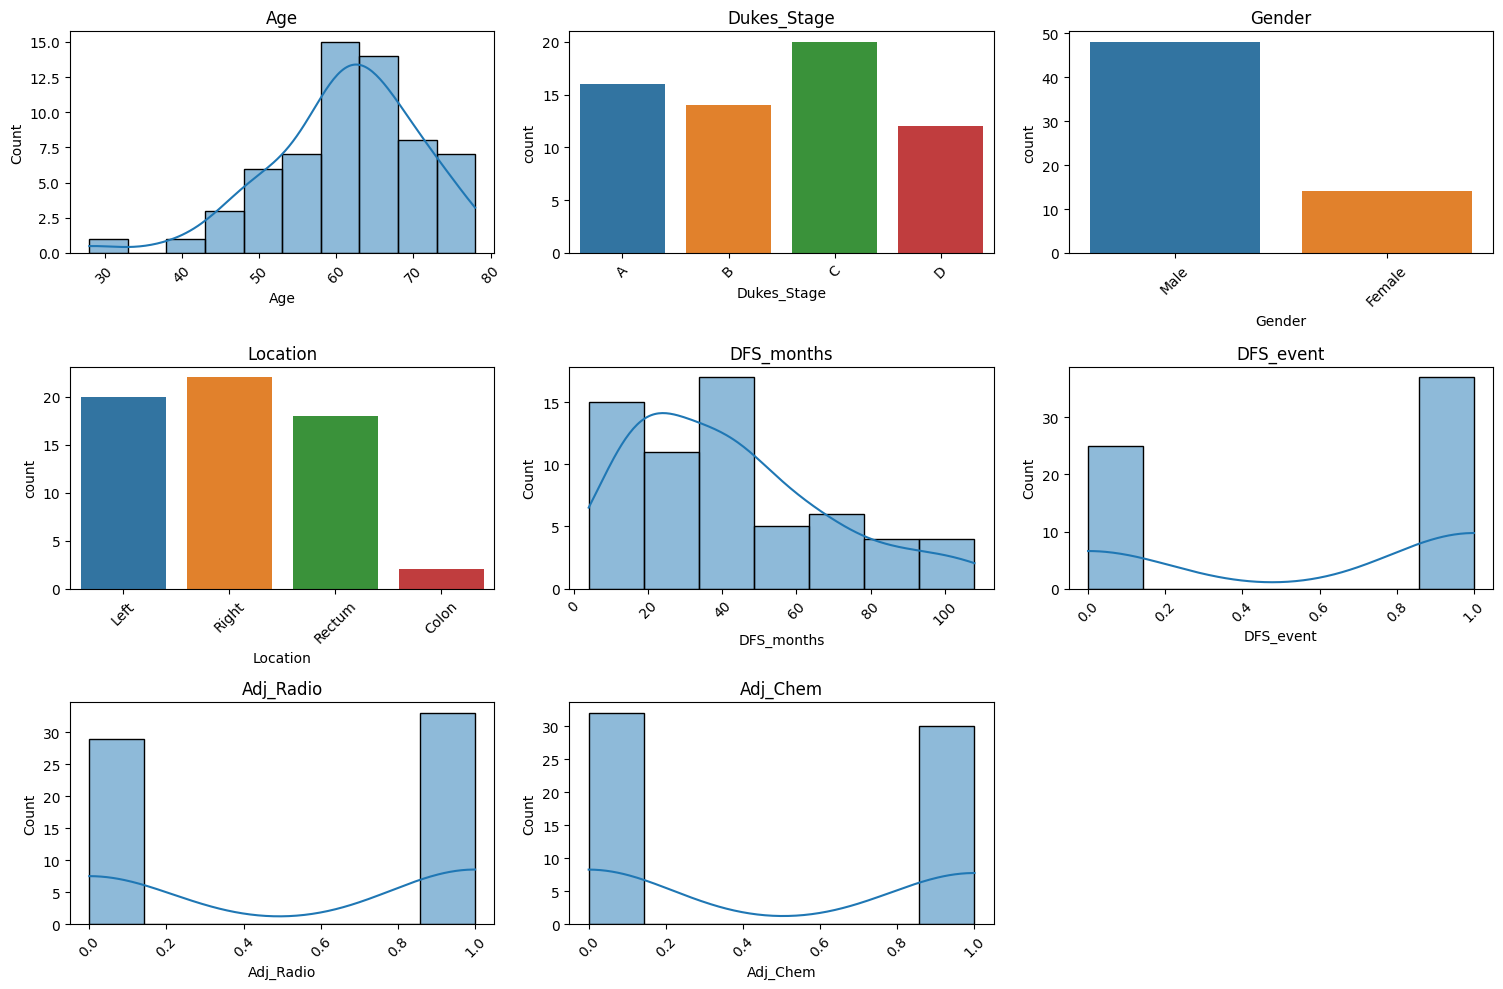

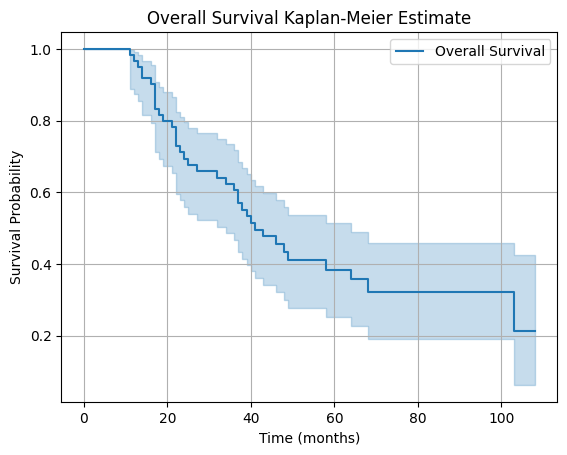

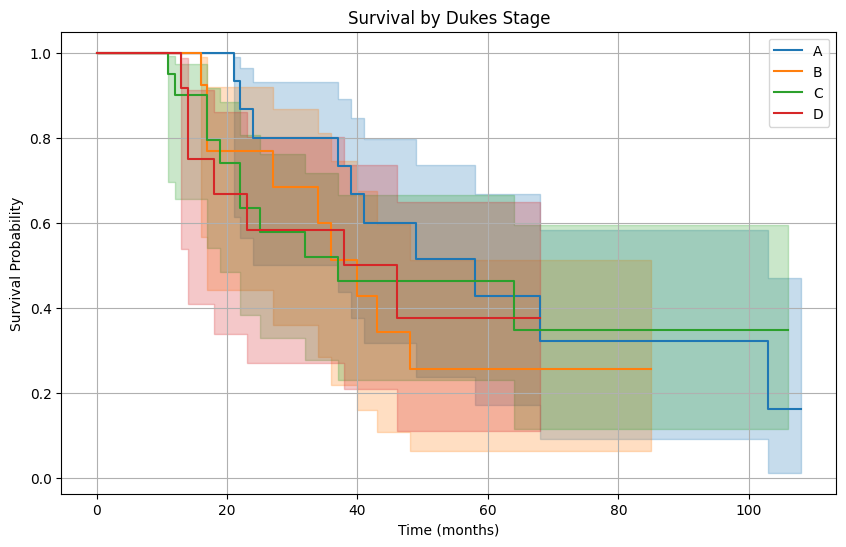


Log-rank Test Results for Dukes Stage:


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.78 0.85      0.23


Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 62 total observations, 25 right-censored observations>
             duration col = 'DFS_months'
                event col = 'DFS_event'
      baseline estimation = breslow
   number of observations = 62
number of events observed = 37
   partial log-likelihood = -126.41
         time fit was run = 2025-07-01 07:56:05 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
Age              0.02      1.02      0.02           -0.01            0.06                0.99                1.06
Adj_Radio       -0.48      0.62      0.36           -1.19            0.23                0.30                1.26
Adj_Chem         0.17      1.19      0.39           -0.59            0.94                0.56                2.55
Dukes_Stage_B    0.76      2.15      0.50           -0.21            1.74                0.81                5.68
Dukes_Stage_C    0.33      1.38      0.47           -0.59            1.24                0.55                3.46
Dukes_Stage_D    0.65      1.92      0.56           -0.44            1.75                0.64                5.75
Gender_Male      0.33      1.40      0.42           -0.49            1.16                0.61                3.19
Location_Left    1.11      3.04      1.15           -1.14            3.36                0.32               28.92
Location_Rectum  1.34      3.80      1.19           -0.99            3.66                0.37               38.81
Location_Right   0.39      1.47      1.12           -1.80            2.57                0.17               13.11

                 cmp to     z    p  -log2(p)
covariate                                   
Age                0.00  1.19 0.24      2.09
Adj_Radio          0.00 -1.32 0.19      2.42
Adj_Chem           0.00  0.45 0.65      0.61
Dukes_Stage_B      0.00  1.54 0.12      3.01
Dukes_Stage_C      0.00  0.70 0.49      1.04
Dukes_Stage_D      0.00  1.17 0.24      2.05
Gender_Male        0.00  0.79 0.43      1.22
Location_Left      0.00  0.97 0.33      1.58
Location_Rectum    0.00  1.13 0.26      1.94
Location_Right     0.00  0.35 0.73      0.46
---
Concordance = 0.62
Partial AIC = 272.81
log-likelihood ratio test = 7.54 on 10 df
-log2(p) of ll-ratio test = 0.57

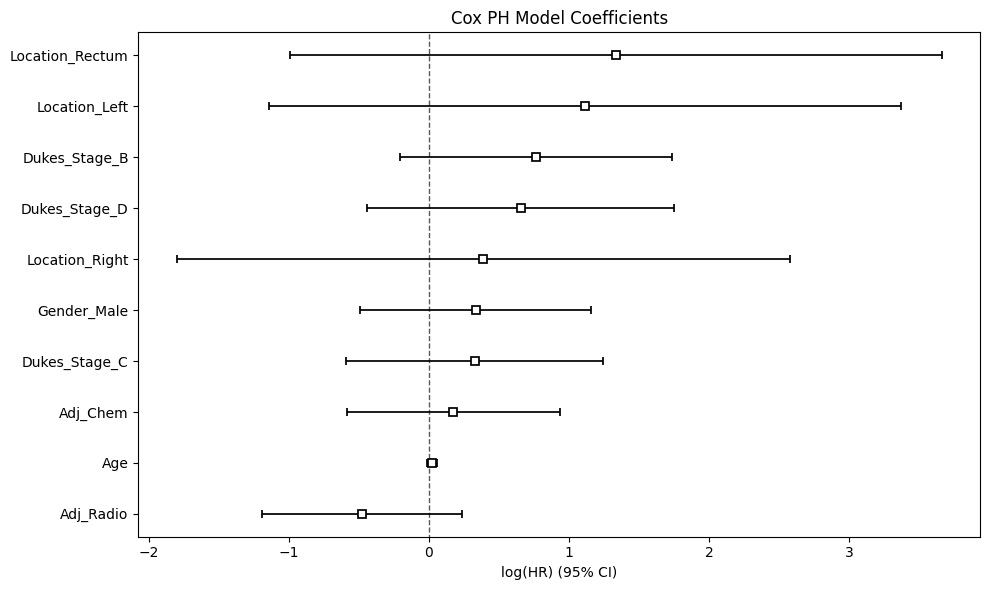


Training SVM Classifier...

SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.50      0.60      0.55         5
         1.0       0.71      0.62      0.67         8

    accuracy                           0.62        13
   macro avg       0.61      0.61      0.61        13
weighted avg       0.63      0.62      0.62        13

AUC: 0.600


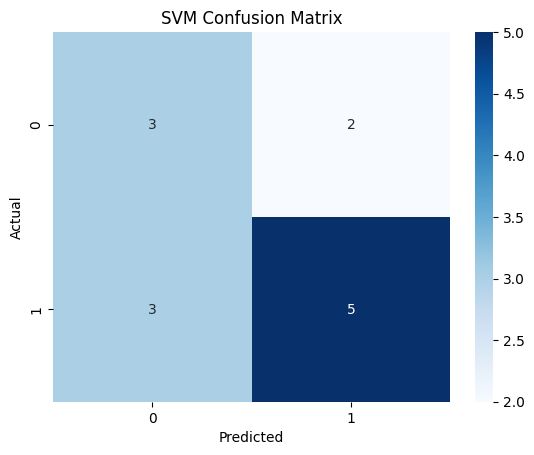


Training Survival SVM...
Survival SVM Concordance Index: 0.619

Training CNN Classifier...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4915 - auc: 0.4890 - loss: 0.7358 - val_accuracy: 0.5385 - val_auc: 0.6750 - val_loss: 0.6848
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5509 - auc: 0.5104 - loss: 0.6988 - val_accuracy: 0.5385 - val_auc: 0.7125 - val_loss: 0.6729
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6026 - auc: 0.4983 - loss: 0.7044 - val_accuracy: 0.6154 - val_auc: 0.6750 - val_loss: 0.6683
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5939 - auc: 0.6173 - loss: 0.6569 - val_accuracy: 0.6154 - val_auc: 0.6375 - val_loss: 0.6679
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4485 - auc: 0.4701 - loss: 0.6945 - val_accuracy: 0.6154 - val_auc: 0.6250 - val_loss: 0.6664
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5337 - auc: 0.5007 - loss: 0.6851 - val_accuracy: 0.6154 - 

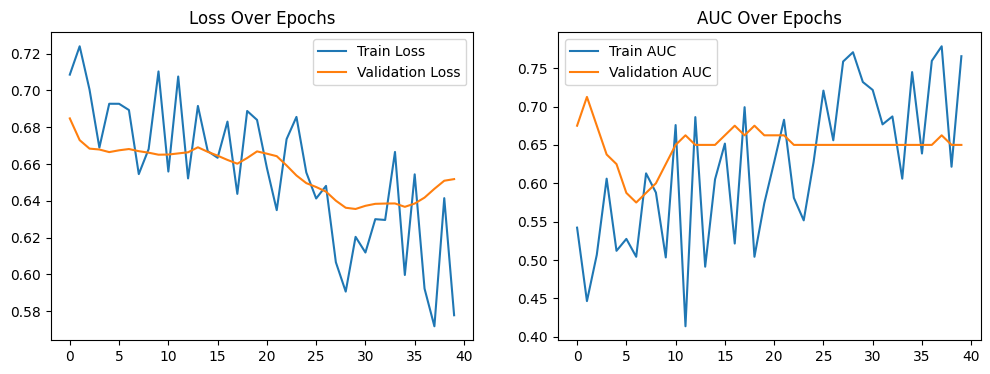


Training Survival CNN...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - event_accuracy: 0.5654 - event_auc: 0.3650 - loss: 1988.7732 - val_event_accuracy: 0.6154 - val_event_auc: 0.3125 - val_loss: 4004.3564
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - event_accuracy: 0.5756 - event_auc: 0.4662 - loss: 1934.0221 - val_event_accuracy: 0.6154 - val_event_auc: 0.5375 - val_loss: 3910.1284
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - event_accuracy: 0.6559 - event_auc: 0.4625 - loss: 1876.7448 - val_event_accuracy: 0.6154 - val_event_auc: 0.5625 - val_loss: 3791.7896
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - event_accuracy: 0.5257 - event_auc: 0.5453 - loss: 1794.6915 - val_event_accuracy: 0.6154 - val_event_auc: 0.6250 - val_loss: 3636.7197
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - event_accuracy: 0.6116 - event_auc: 0.6544 - loss: 1686.9187 - val_event_accuracy: 0.6154 - val_event_auc: 0.6500 - val_loss: 3428.8286
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.feature_selection import SelectKBest, f_classif
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, concatenate
from tensorflow.keras.callbacks import EarlyStopping
from sksurv.svm import FastSurvivalSVM
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 1. Data Loading and Preprocessing
# Load the dataset
df = pd.read_csv('/kaggle/input/colorectal-cancer-patients/Colorectal Cancer Patient Data.csv')

# Data cleaning and preparation
df_cleaned = df.drop(columns=['Unnamed: 0', 'ID_REF']).dropna()
df_cleaned.columns = ['Age', 'Dukes_Stage', 'Gender', 'Location', 'DFS_months', 'DFS_event', 'Adj_Radio', 'Adj_Chem']

# Display basic info
print("Data Overview:")
print(df_cleaned.info())
print("\nSummary Statistics:")
print(df_cleaned.describe())

# Visualize distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_cleaned.columns):
    plt.subplot(3, 3, i+1)
    if df_cleaned[col].dtype in ['float64', 'int64']:
        sns.histplot(df_cleaned[col], kde=True)
    else:
        sns.countplot(data=df_cleaned, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Traditional Survival Analysis
# Kaplan-Meier survival curve
kmf = KaplanMeierFitter()
kmf.fit(df_cleaned['DFS_months'], df_cleaned['DFS_event'], label='Overall Survival')
kmf.plot_survival_function()
plt.title('Overall Survival Kaplan-Meier Estimate')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

# Survival by Dukes Stage
plt.figure(figsize=(10, 6))
for stage in df_cleaned['Dukes_Stage'].unique():
    mask = df_cleaned['Dukes_Stage'] == stage
    kmf.fit(df_cleaned['DFS_months'][mask], df_cleaned['DFS_event'][mask], label=stage)
    kmf.plot_survival_function()
plt.title('Survival by Dukes Stage')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()

# Log-rank test for Dukes Stage
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Dukes_Stage'], df_cleaned['DFS_event'])
print("\nLog-rank Test Results for Dukes Stage:")
results.print_summary()

# Cox Proportional Hazards Model
df_for_cph = pd.get_dummies(df_cleaned, columns=['Dukes_Stage', 'Gender', 'Location'], drop_first=True)
cph = CoxPHFitter()
cph.fit(df_for_cph, duration_col='DFS_months', event_col='DFS_event')
print("\nCox Proportional Hazards Model Summary:")
cph.print_summary()

# Plot Cox model coefficients
plt.figure(figsize=(10, 6))
cph.plot()
plt.title('Cox PH Model Coefficients')
plt.tight_layout()
plt.show()

## 3. Machine Learning Approaches
### 3.1 Data Preparation for ML Models
# Feature engineering
df_cleaned['Age_Group'] = pd.cut(df_cleaned['Age'], bins=[0,50,60,70,100], 
                                labels=['<50','50-60','60-70','70+'])

# Prepare features and targets
X = pd.get_dummies(df_cleaned.drop(['DFS_months', 'DFS_event'], axis=1))
y = df_cleaned['DFS_event']  # For classification
y_surv = np.array([(event, time) for event, time in zip(df_cleaned['DFS_event'], df_cleaned['DFS_months'])],
                 dtype=[('event', 'bool'), ('time', 'f8')])  # For survival models

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
train_idx, test_idx = train_test_split(np.arange(len(df_cleaned)), test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3.2 Support Vector Machines (SVM)
# Binary Classification SVM
print("\nTraining SVM Classifier...")
svm_model = SVC(kernel='rbf', probability=True, class_weight='balanced', random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Evaluate SVM classifier
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred))
print(f"AUC: {roc_auc_score(y_test, y_proba):.3f}")

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Survival SVM (ranking approach)
print("\nTraining Survival SVM...")
surv_svm = FastSurvivalSVM(max_iter=1000, tol=1e-5, random_state=42)
surv_svm.fit(X_train_scaled, y_surv[train_idx])

# Evaluate survival SVM
risk_scores = surv_svm.predict(X_test_scaled)
surv_svm_c_index = concordance_index_censored(y_surv[test_idx]['event'], y_surv[test_idx]['time'], risk_scores)[0]
print(f"Survival SVM Concordance Index: {surv_svm_c_index:.3f}")

### 3.3 Convolutional Neural Network (CNN)
# Reshape data for 1D CNN
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Build 1D CNN model for classification
print("\nTraining CNN Classifier...")
model = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', 
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train CNN classifier
history = model.fit(X_train_reshaped, y_train, epochs=100, batch_size=8,
                   validation_data=(X_test_reshaped, y_test), 
                   callbacks=[early_stop], verbose=1)

# Evaluate CNN classifier
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.title('AUC Over Epochs')
plt.legend()
plt.show()

# Survival CNN (multi-task learning)
print("\nTraining Survival CNN...")
inputs = Input(shape=(X_train_reshaped.shape[1], 1))
x = Conv1D(32, 3, activation='relu')(inputs)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(2)(x)
x = Dropout(0.3)(x)
x = Flatten()(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.5)(x)

# Two outputs: event prediction and time prediction
event_out = Dense(1, activation='sigmoid', name='event')(x)
time_out = Dense(1, activation='relu', name='time')(x)

surv_model = Model(inputs=inputs, outputs=[event_out, time_out])
surv_model.compile(optimizer='adam', 
                  loss={'event': 'binary_crossentropy', 'time': 'mse'},
                  metrics={'event': ['accuracy', tf.keras.metrics.AUC(name='auc')]})

# Train survival CNN
surv_history = surv_model.fit(X_train_reshaped, 
                             {'event': y_train, 'time': df_cleaned.loc[y_train.index, 'DFS_months']},
                             epochs=100, batch_size=8,
                             validation_data=(X_test_reshaped, 
                                            {'event': y_test, 
                                             'time': df_cleaned.loc[y_test.index, 'DFS_months']}),
                             callbacks=[early_stop], verbose=1)

# Evaluate survival CNN
time_pred = surv_model.predict(X_test_reshaped)[1].flatten()
cnn_c_index = concordance_index_censored(y_surv[test_idx]['event'], 
                                    y_surv[test_idx]['time'], 
                                    -time_pred)[0]
print(f"Survival CNN Concordance Index: {cnn_c_index:.3f}")

## 4. Random Survival Forest (Comparison)
print("\nTraining Random Survival Forest...")
rsf = RandomSurvivalForest(n_estimators=100, min_samples_split=10, 
                          min_samples_leaf=5, n_jobs=-1, random_state=42)
rsf.fit(X_train_scaled, y_surv[train_idx])

# Evaluate RSF
rsf_risk_scores = rsf.predict(X_test_scaled)
rsf_c_index = concordance_index_censored(y_surv[test_idx]['event'], 
                                        y_surv[test_idx]['time'], 
                                        rsf_risk_scores)[0]
print(f"Random Survival Forest Concordance Index: {rsf_c_index:.3f}")

## 5. Model Comparison
print("\nModel Performance Comparison:")
print(f"SVM Classifier AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"CNN Classifier AUC: {model.evaluate(X_test_reshaped, y_test, verbose=0)[2]:.3f}")
print(f"Survival SVM C-index: {c_index:.3f}")
print(f"Survival CNN C-index: {c_index:.3f}")
print(f"Random Survival Forest C-index: {rsf_c_index:.3f}")

In [31]:
from sksurv.metrics import concordance_index_censored

# Kaplan-Meier Proxy C-index using Dukes Stage group medians
group_medians = df_cleaned.groupby('Dukes_Stage')['DFS_months'].median().to_dict()

# Assign proxy risk score = negative median survival (higher = worse prognosis)
km_proxy_scores = df_cleaned['Dukes_Stage'].map(lambda x: -group_medians[x])

# Compute C-index using proxy scores
c_index_km_proxy = concordance_index_censored(
    df_cleaned['DFS_event'].astype(bool),
    df_cleaned['DFS_months'],
    km_proxy_scores
)[0]

print(f"Kaplan-Meier Proxy Concordance Index (Dukes Stage groups): {c_index_km_proxy:.3f}")


Kaplan-Meier Proxy Concordance Index (Dukes Stage groups): 0.558


In [32]:
import pandas as pd
c_index_cox=0.62

comparison_df = pd.DataFrame({
    'Model': [
        'SVM Classifier', 
        'CNN Classifier',
        'Survival SVM',
        'Survival CNN',
        'Random Survival Forest',
        'Cox PH Model',
        'Kaplan-Meier Proxy (Dukes Stage)'
    ],
    'Metric': [
        'AUC', 'AUC', 
        'C-index', 'C-index', 
        'C-index', 'C-index', 
        'C-index'
    ],
    'Score': [
        roc_auc_score(y_test, y_proba),
        model.evaluate(X_test_reshaped, y_test, verbose=0)[2],
        surv_svm_c_index,           # capture earlier: surv_svm_c_index = ...
        cnn_c_index,                # capture earlier: cnn_c_index = ...
        rsf_c_index,
        c_index_cox,                # from Cox model
        c_index_km_proxy            # from KM proxy
    ]
})

print("\nModel Performance Summary:")
print(comparison_df.sort_values(by='Score', ascending=False))



Model Performance Summary:
                              Model   Metric     Score
4            Random Survival Forest  C-index  0.666667
1                    CNN Classifier      AUC  0.650000
5                      Cox PH Model  C-index  0.620000
2                      Survival SVM  C-index  0.619048
0                    SVM Classifier      AUC  0.600000
6  Kaplan-Meier Proxy (Dukes Stage)  C-index  0.557636
3                      Survival CNN  C-index  0.492063


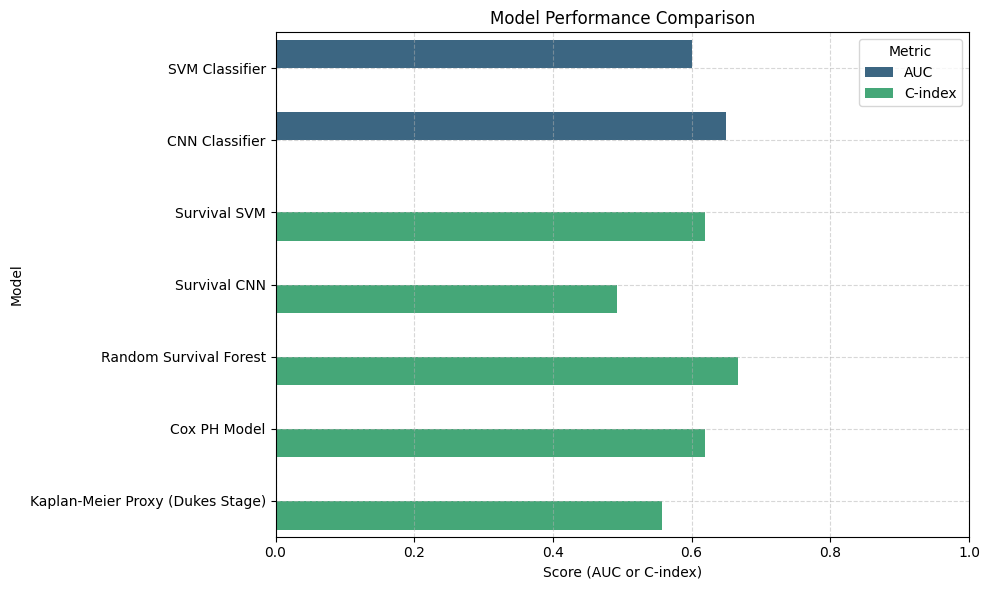

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Score', y='Model', hue='Metric', palette='viridis')
plt.title('Model Performance Comparison')
plt.xlabel('Score (AUC or C-index)')
plt.xlim(0, 1)
plt.legend(title='Metric')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [36]:
from lifelines.statistics import multivariate_logrank_test

print("# Example for Gender")
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Gender'], df_cleaned['DFS_event'])
results.print_summary()

print("# Example for Dukes_Stage")
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Dukes_Stage'], df_cleaned['DFS_event'])
results.print_summary()

print("# Example for Location")
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Location'], df_cleaned['DFS_event'])
results.print_summary()


print("# Example for Adj_Chem,")
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Adj_Chem'], df_cleaned['DFS_event'])
results.print_summary()

print("# Example for Adj_Radio")
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Adj_Radio'], df_cleaned['DFS_event'])
results.print_summary()


print("# Example for Age_Group")
results = multivariate_logrank_test(df_cleaned['DFS_months'], df_cleaned['Age_Group'], df_cleaned['DFS_event'])
results.print_summary()




# Example for Gender


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.16 0.69      0.54

# Example for Dukes_Stage


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.78 0.85      0.23

# Example for Location


...

<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.01 0.93      0.10

# Example for Adj_Radio


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.38 0.54      0.90

# Example for Age_Group


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           8.66 0.03      4.87

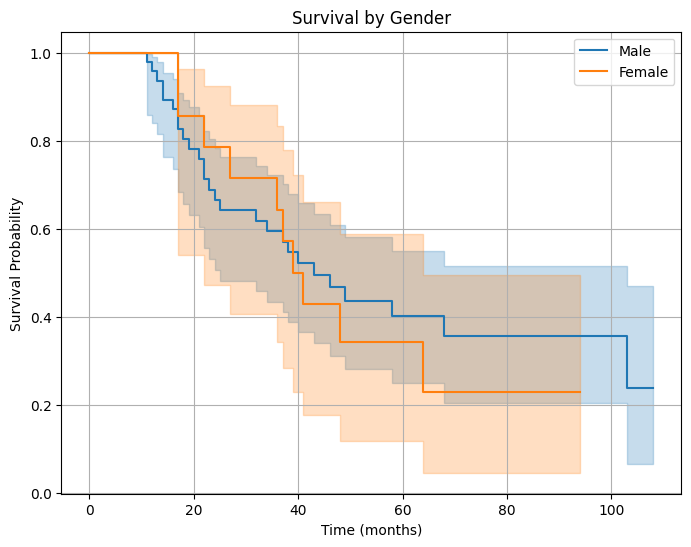

In [39]:
# KM for Gender
plt.figure(figsize=(8, 6))
for gender in df_cleaned['Gender'].unique():
    mask = df_cleaned['Gender'] == gender
    kmf.fit(df_cleaned['DFS_months'][mask], df_cleaned['DFS_event'][mask], label=gender)
    kmf.plot_survival_function()
plt.title('Survival by Gender')
plt.xlabel('Time (months)')
plt.ylabel('Survival Probability')
plt.grid(True)
plt.show()


In [40]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt

def plot_km_and_logrank_for_categoricals(df, time_col='DFS_months', event_col='DFS_event', min_categories=2, max_categories=6):
    """
    Generate Kaplan-Meier plots and log-rank tests for all suitable categorical features.
    
    Parameters:
    - df: pandas DataFrame with survival data
    - time_col: name of column with survival time
    - event_col: name of column with event occurrence (1 = event, 0 = censored)
    - min_categories: minimum number of unique values in a column to be included
    - max_categories: maximum number of categories to plot
    """
    kmf = KaplanMeierFitter()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns

    for col in cat_cols:
        unique_vals = df[col].nunique()
        if min_categories <= unique_vals <= max_categories:
            print(f"\n▶ Feature: {col} ({unique_vals} categories)")

            # Log-rank test
            results = multivariate_logrank_test(df[time_col], df[col], df[event_col])
            results.print_summary()

            # KM plot
            plt.figure(figsize=(8, 6))
            for category in df[col].unique():
                mask = df[col] == category
                kmf.fit(df[time_col][mask], df[event_col][mask], label=str(category))
                kmf.plot_survival_function()
            
            plt.title(f"Kaplan-Meier Curve by {col}")
            plt.xlabel('Time (months)')
            plt.ylabel('Survival Probability')
            plt.grid(True)
            plt.legend(title=col)
            plt.tight_layout()
            plt.show()



▶ Feature: Dukes_Stage (4 categories)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.78 0.85      0.23

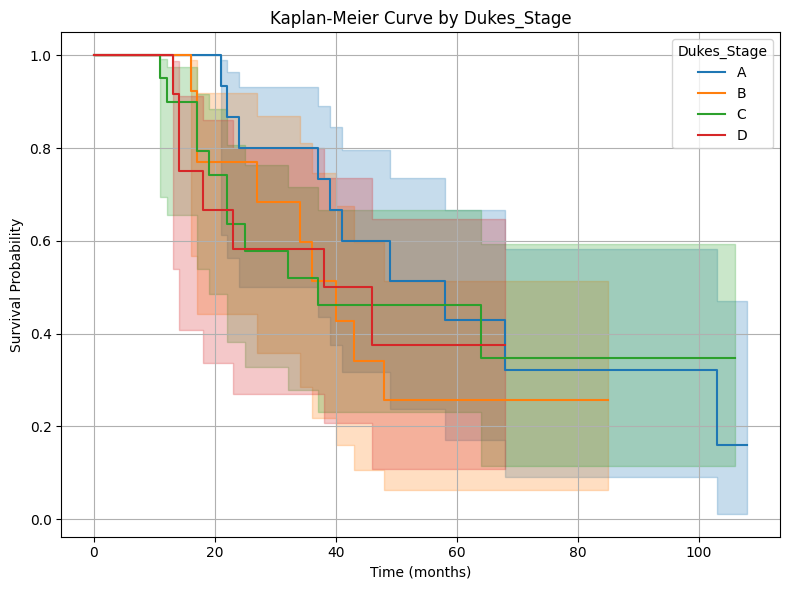


▶ Feature: Gender (2 categories)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           0.16 0.69      0.54

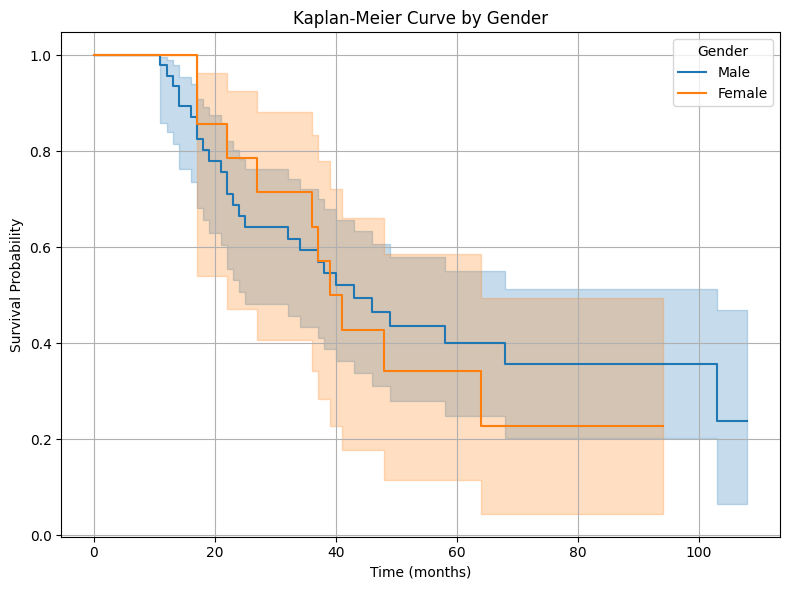


▶ Feature: Location (4 categories)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           2.73 0.43      1.20

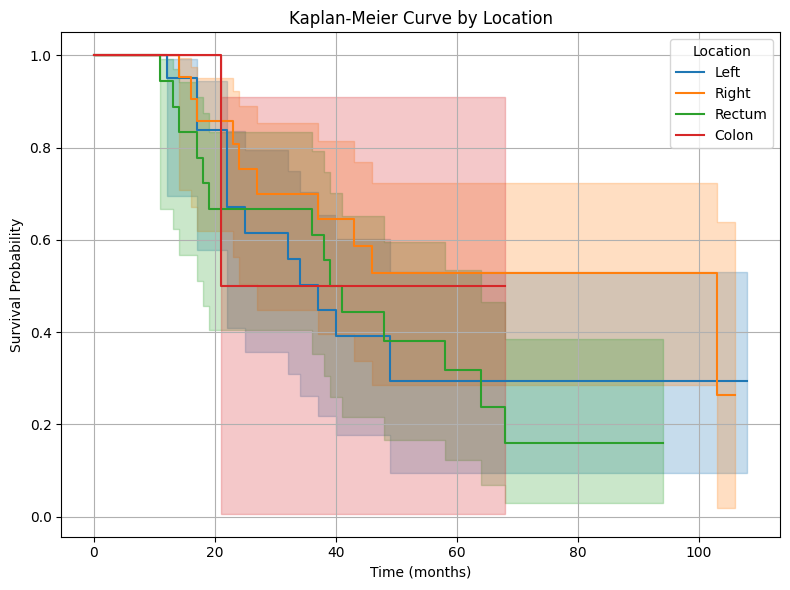


▶ Feature: Age_Group (4 categories)


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           8.66 0.03      4.87

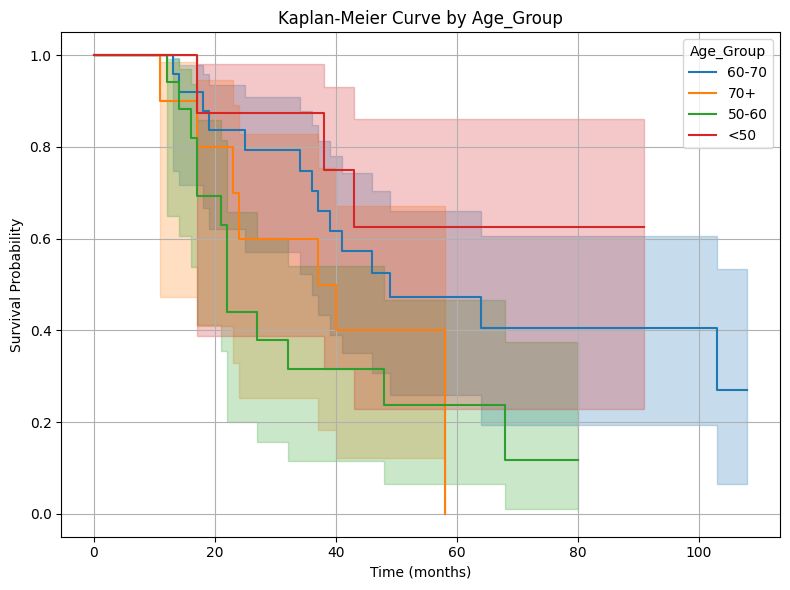

In [41]:
plot_km_and_logrank_for_categoricals(df_cleaned)
